In [16]:
import sys
from pathlib import Path

def encontrar_raiz_repo(marcador=".git"):
    caminho = Path.cwd()
    for pasta in [caminho, *caminho.parents]:
        if (pasta / marcador).exists():
            return pasta
    raise FileNotFoundError(f"Não achei {marcador} subindo a partir de {caminho}")

RAIZ = encontrar_raiz_repo()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.clustering import Clustering
import pandas as pd

## Carregando os dados

In [17]:
df_train = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_train.csv", index_col=0)
df_valid = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_valid.csv", index_col=0)
df_test = pd.read_csv(RAIZ / "data/processed/df_estruturada/df_test.csv", index_col=0)

print(df_train.shape)
df_train.head()

(4926, 11)


,pct_genes_cromossomal_efflux,mdr_score_cromossomal,mdr_score_plasmidial,pct_contigs_plasmidial,pct_plasmidial_amr,pct_plasmidial_conjugacao_amr,n_proviruses_por_mb,gc_diff_plasmid_cromossomo,virulence_score_cromossomal,virulence_score_plasmidial,cat_plasmidial_beta-lactam
sample,,,,,,,,,,,
GCA_021009385.1,7.142857,13,3,11.818182,30.769231,0.000000,1.662461,0.33,6,4,0
GCA_015825355.1,12.500000,3,0,1.666667,0.000000,0.000000,0.942911,-6.27,6,0,0
GCA_038594105.1,1.785714,12,7,14.925373,10.000000,3.333333,0.842382,-1.08,8,3,1
GCA_019201995.1,1.785714,14,5,21.487603,7.692308,0.000000,1.323753,-1.00,8,2,0
GCA_038066875.1,25.000000,4,3,25.668449,4.166667,0.000000,0.841943,-0.31,3,1,0


In [18]:
metadata_cols = pd.read_csv(RAIZ / "data/processed/metadata_filtrada.csv")

metadata_cols = metadata_cols.set_index('sample')
metadata_cols.head()

,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,
GCA_000216055.2,Leptospira interrogans,Homo sapiens,NaN,Salvador,SAMN00254327,BA,Nordeste,Other,Other
GCA_000316425.1,Escherichia coli,NaN,1990.0,Brazil,SAMN01041333,NaN,NaN,Unknown,Critical
GCA_000223095.2,Vibrio cholerae,patient with cholera-like diarrhea,1991.0,NaN,SAMN02470783,NaN,NaN,Gastrointestinal,Other
GCA_036761135.1,Acinetobacter bereziniae,Rectal Swab,2019.0,Brazil,SAMN39408214,NaN,NaN,Gastrointestinal,Other
GCA_003670255.1,Acinetobacter bereziniae,Endotracheal aspirate,2014.0,"Londrina, PR",SAMN09907131,PR,Sul,Respiratory,Other


In [19]:
metadata_alinhado = metadata_cols.loc[df_train.index]

print(metadata_alinhado.shape)
metadata_alinhado.head()

(4926, 9)


,Species,Source,Date,Location,BioSample,Estado,Região,source_type,WHO_Priority
sample,,,,,,,,,
GCA_021009385.1,Staphylococcus aureus,Nasal Colonization,2016.0,Rio de Janeiro,SAMN16946800,RJ,Sudeste,Respiratory,High
GCA_015825355.1,Neisseria meningitidis,cerebrospinal fluid,2016.0,"Sao Paulo, Sao Paulo",SAMN10873099,SP,Sul,CNS,Other
GCA_038594105.1,Pseudomonas aeruginosa,Surveillance swab,2023.0,"Sao Paulo, Sao Paulo",SAMN40996642,SP,Sul,Other,High
GCA_019201995.1,Escherichia coli,urine,2014.0,Uberlandia,SAMN14464882,NaN,NaN,Urinary,Critical
GCA_038066875.1,Burkholderia contaminans,blood,2023.0,Sao Paulo,SAMN40603088,SP,Sul,Blood,Other


In [20]:
top_especies = metadata_alinhado["Species"].value_counts().nlargest(10).index

especie_plot_completo = metadata_alinhado["Species"].where(
    metadata_alinhado["Species"].isin(top_especies), "Outras"
)

especie_plot_completo.head()

sample
GCA_021009385.1     Staphylococcus aureus
GCA_015825355.1    Neisseria meningitidis
GCA_038594105.1    Pseudomonas aeruginosa
GCA_019201995.1          Escherichia coli
GCA_038066875.1                    Outras
Name: Species, dtype: object

In [21]:
colunas_X = ['pct_genes_cromossomal_efflux', 'mdr_score_cromossomal',
       'mdr_score_plasmidial', 'pct_contigs_plasmidial', 'pct_plasmidial_amr',
       'pct_plasmidial_conjugacao_amr', 'n_proviruses_por_mb',
       'gc_diff_plasmid_cromossomo', 'virulence_score_cromossomal',
       'virulence_score_plasmidial', 'cat_plasmidial_beta-lactam']

In [ ]:
colunas_X_menor = ['pct_genes_cromossomal_efflux', 'mdr_score_cromossomal',
       'mdr_score_plasmidial', 'pct_plasmidial_amr',
       'virulence_score_plasmidial', 'cat_plasmidial_beta-lactam']

In [23]:
transformacoes = ["sem_scaling", "standard", "minmax"]

## K-means

=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10}
Silhouette Score Médio (CV): 0.4127

Silhouette Score -> 0.414
Calinski Harabasz Score -> 2760.053
Davies Bouldin Score -> 1.101


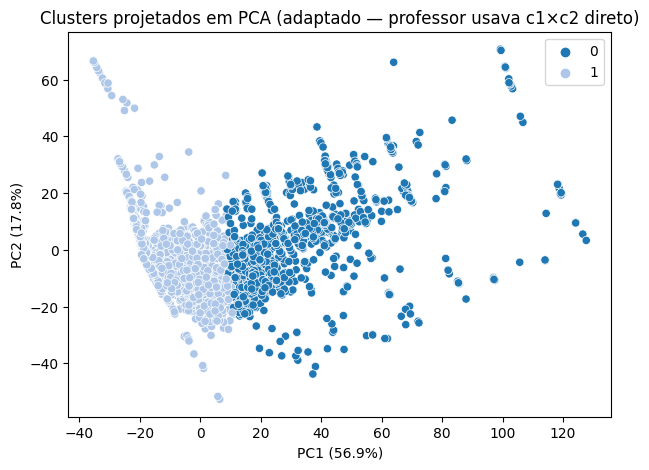

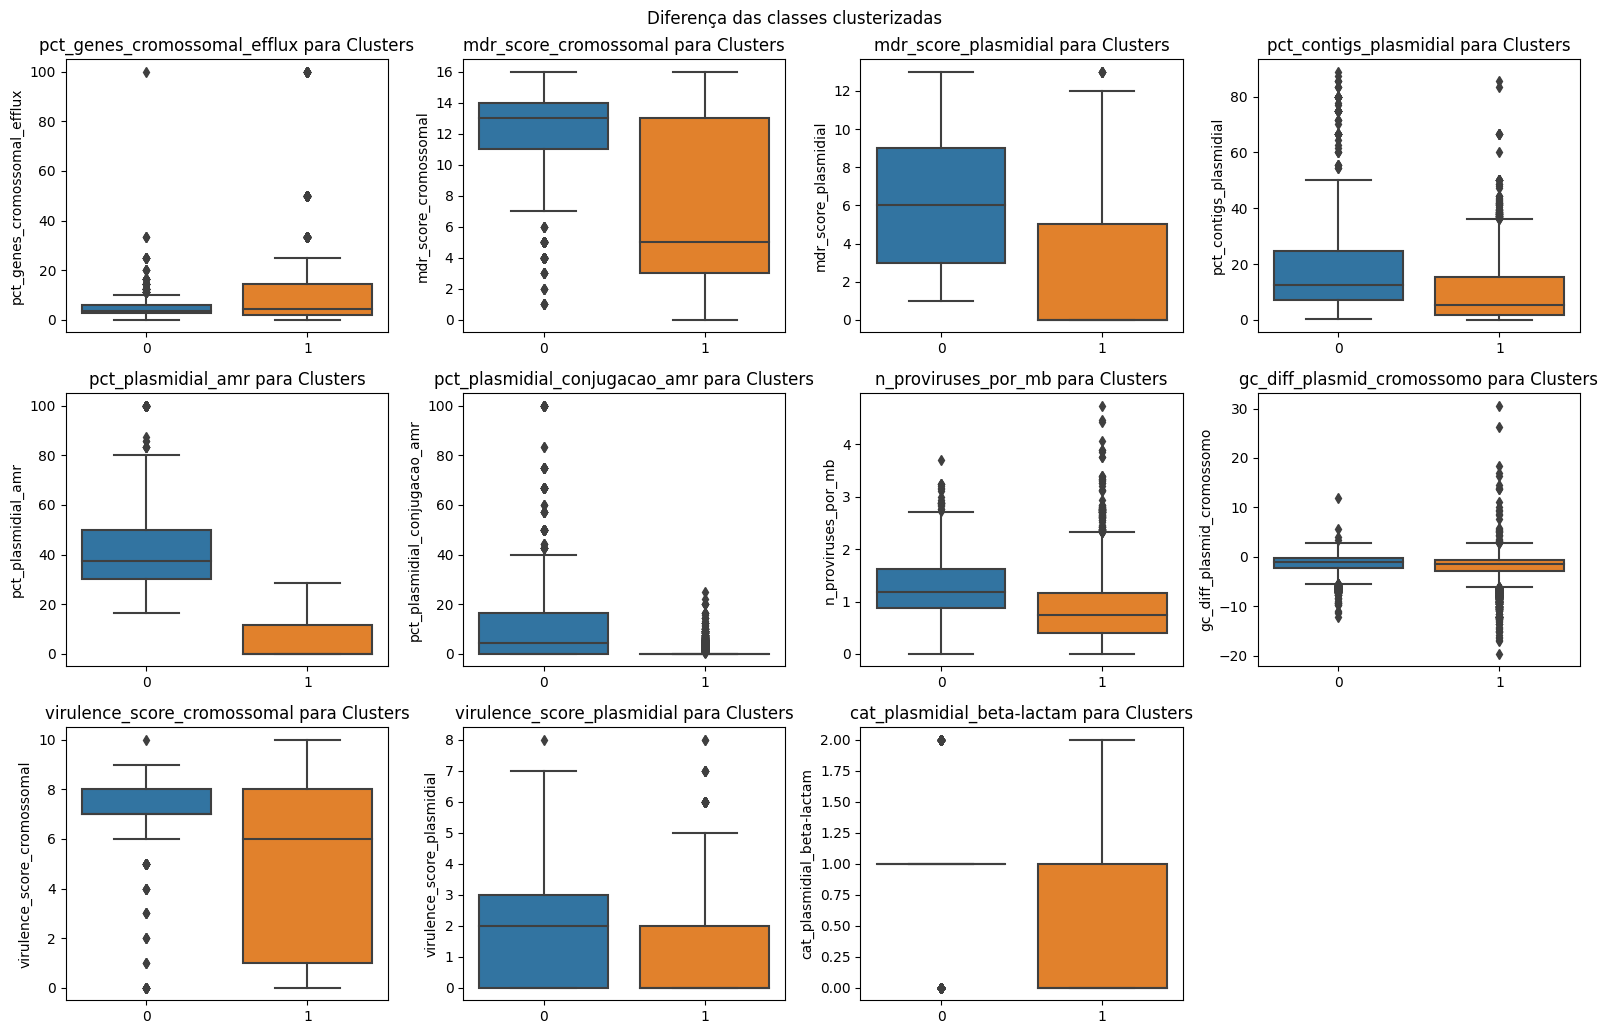

In [24]:
cluster_kmeans = Clustering(colunas_X, df_train, "kmeans")
tabela_cv_kmeans = cluster_kmeans.cross_validation(transformacao="sem_scaling")

In [25]:
tabela_cv_kmeans

,n_clusters,init,n_init,mean_score,std_score
0,2,k-means++,auto,0.412610,0.018577
1,2,k-means++,10,0.412715,0.022502
2,2,k-means++,20,0.411591,0.022048
3,2,random,auto,0.411574,0.022075
4,2,random,10,0.411574,0.022075
5,2,random,20,0.411574,0.022075
6,3,k-means++,auto,0.389614,0.006996
7,3,k-means++,10,0.391632,0.006401
8,3,k-means++,20,0.391604,0.006382
9,3,random,auto,0.390241,0.005989


sem_scaling: {'silhouette': 0.414, 'calinski_harabasz': 2760.053, 'davies_bouldin': 1.101, 'ari': nan, 'ami': nan}
=== MELHOR CONFIGURAÇÃO ENCONTRADA VIA cross_val_score ===
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10}
Silhouette Score Médio (CV): 0.4454

Silhouette Score -> 0.446
Calinski Harabasz Score -> 4895.252
Davies Bouldin Score -> 0.908


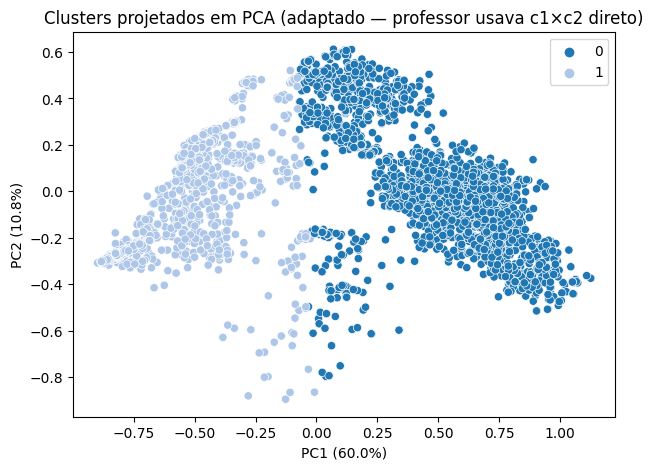

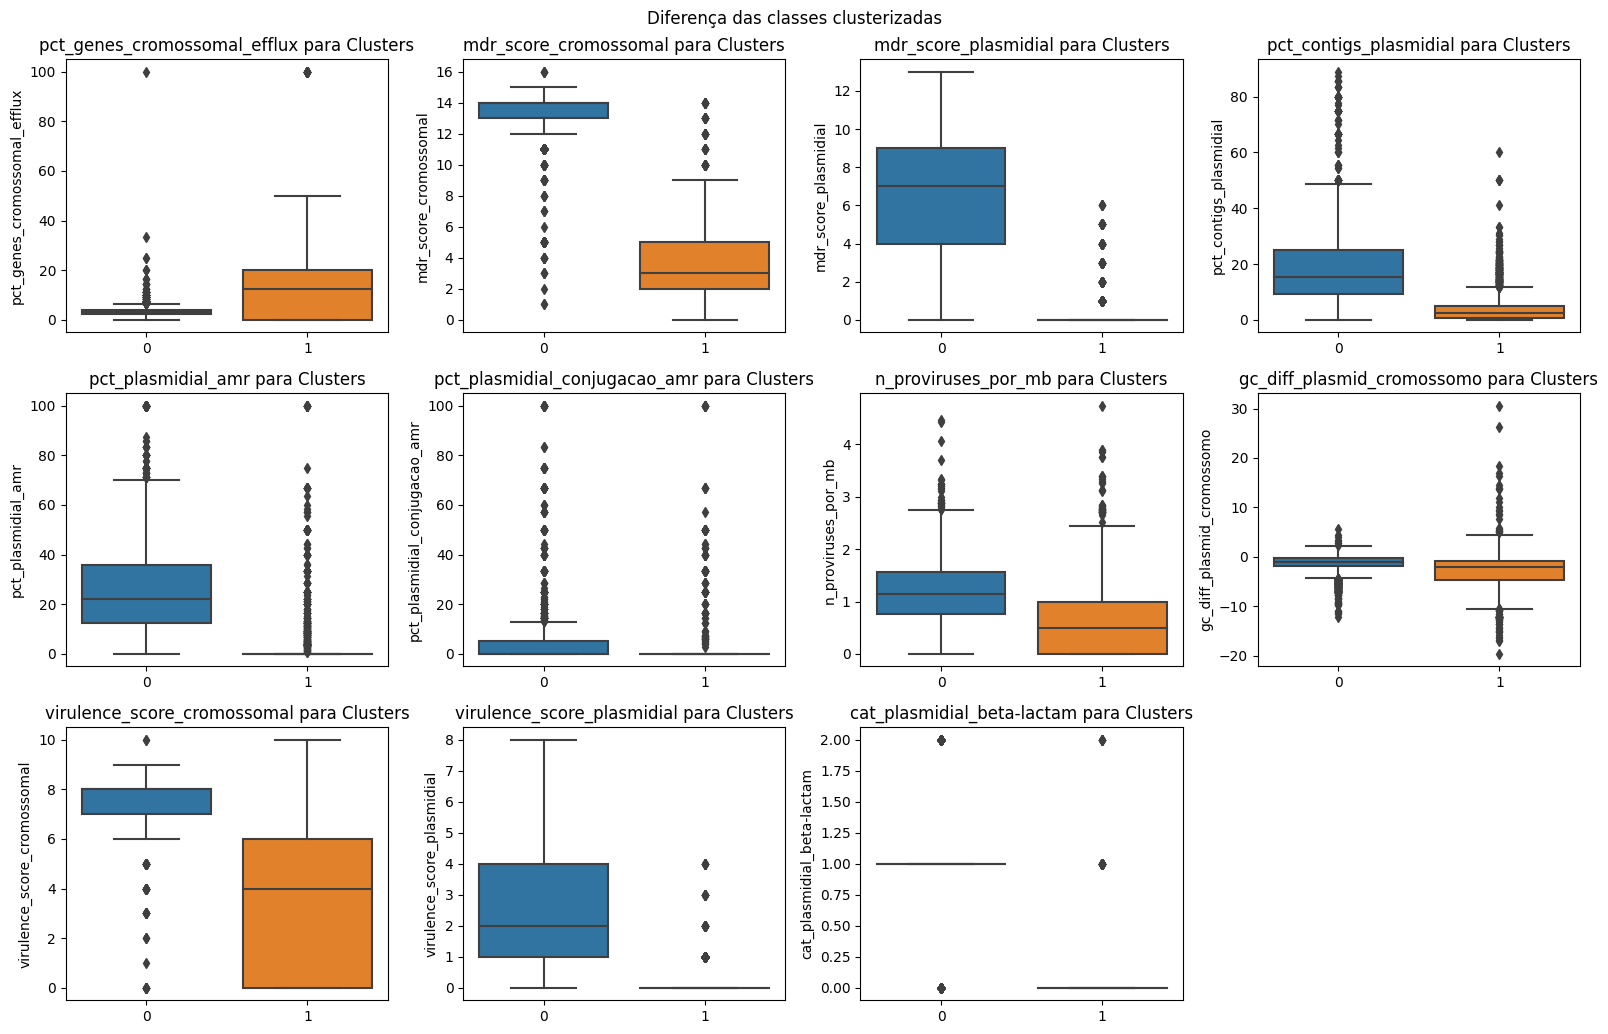

minmax: {'silhouette': 0.446, 'calinski_harabasz': 4895.252, 'davies_bouldin': 0.908, 'ari': nan, 'ami': nan}


In [14]:
print("sem_scaling:", cluster_kmeans.metricas_)

cluster_kmeans_mm = Clustering(colunas_X, df_train, "kmeans")
cluster_kmeans_mm.cross_validation(transformacao="minmax")
print("minmax:", cluster_kmeans_mm.metricas_)

In [15]:
  # array de rótulos do modelo final
cluster_kmeans_mm.tabela_grid_     # a mesma tabela que já tinha em mãos (redundante com o retorno, só por conveniência)

,n_clusters,init,n_init,mean_score,std_score
0,2,k-means++,auto,0.445401,0.005570
1,2,k-means++,10,0.445434,0.005617
2,2,k-means++,20,0.445434,0.005617
3,2,random,auto,0.445434,0.005617
4,2,random,10,0.445434,0.005617
5,2,random,20,0.445434,0.005617
6,3,k-means++,auto,0.361819,0.013114
7,3,k-means++,10,0.365644,0.005583
8,3,k-means++,20,0.365853,0.005878
9,3,random,auto,0.365616,0.005544


In [10]:
tabela_cv_kmeans.style \
    .apply(
        lambda s: destacar_top2(s, metricas[s.name]),
        subset=list(metricas.keys())
    )

NameError: name 'metricas' is not defined

In [ ]:
cluster_kmeans.ajustar(n_clusters=5, init="k-means++", n_init="auto")
cluster_kmeans.calcular_metricas()

Calculando métricas para: kmeans

Silhouette Score -> 0.325
Calinski Harabasz Score -> 2338.112
Davies Bouldin Score -> 1.484


{'silhouette': 0.325, 'calinski_harabasz': 2338.112, 'davies_bouldin': 1.484}

In [ ]:
resultado_valid = cluster_kmeans.validar_do_zero(df_valid, nome="valid")


--- Validação do zero em 'valid' (kmeans, minmax) ---
Calculando métricas para: kmeans (valid)

Silhouette Score -> 0.347
Calinski Harabasz Score -> 423.681
Davies Bouldin Score -> 1.268
Qui-quadrado (distribuição de tamanho de cluster): chi2=1107.96, p=0.0000


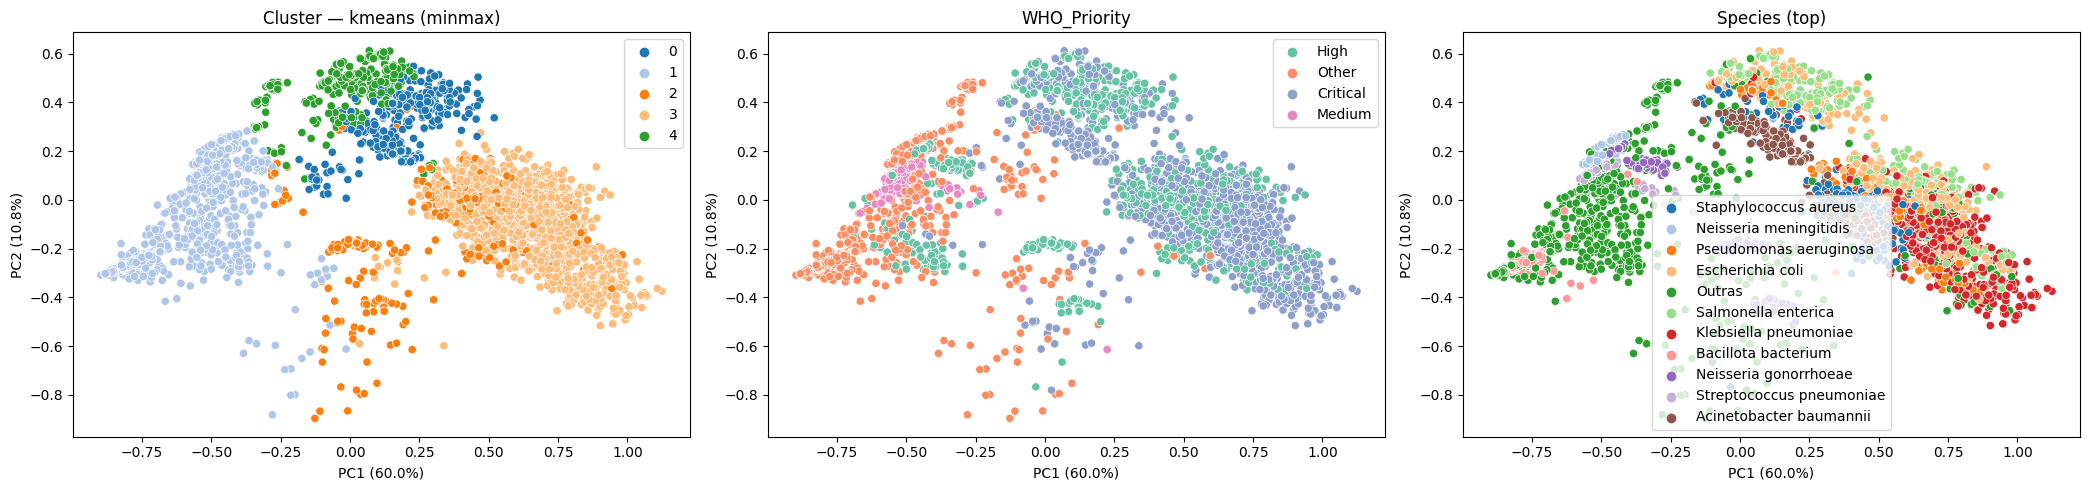

In [ ]:
cluster_kmeans._plot_com_pca(metadata_alinhado, especie_plot_completo)

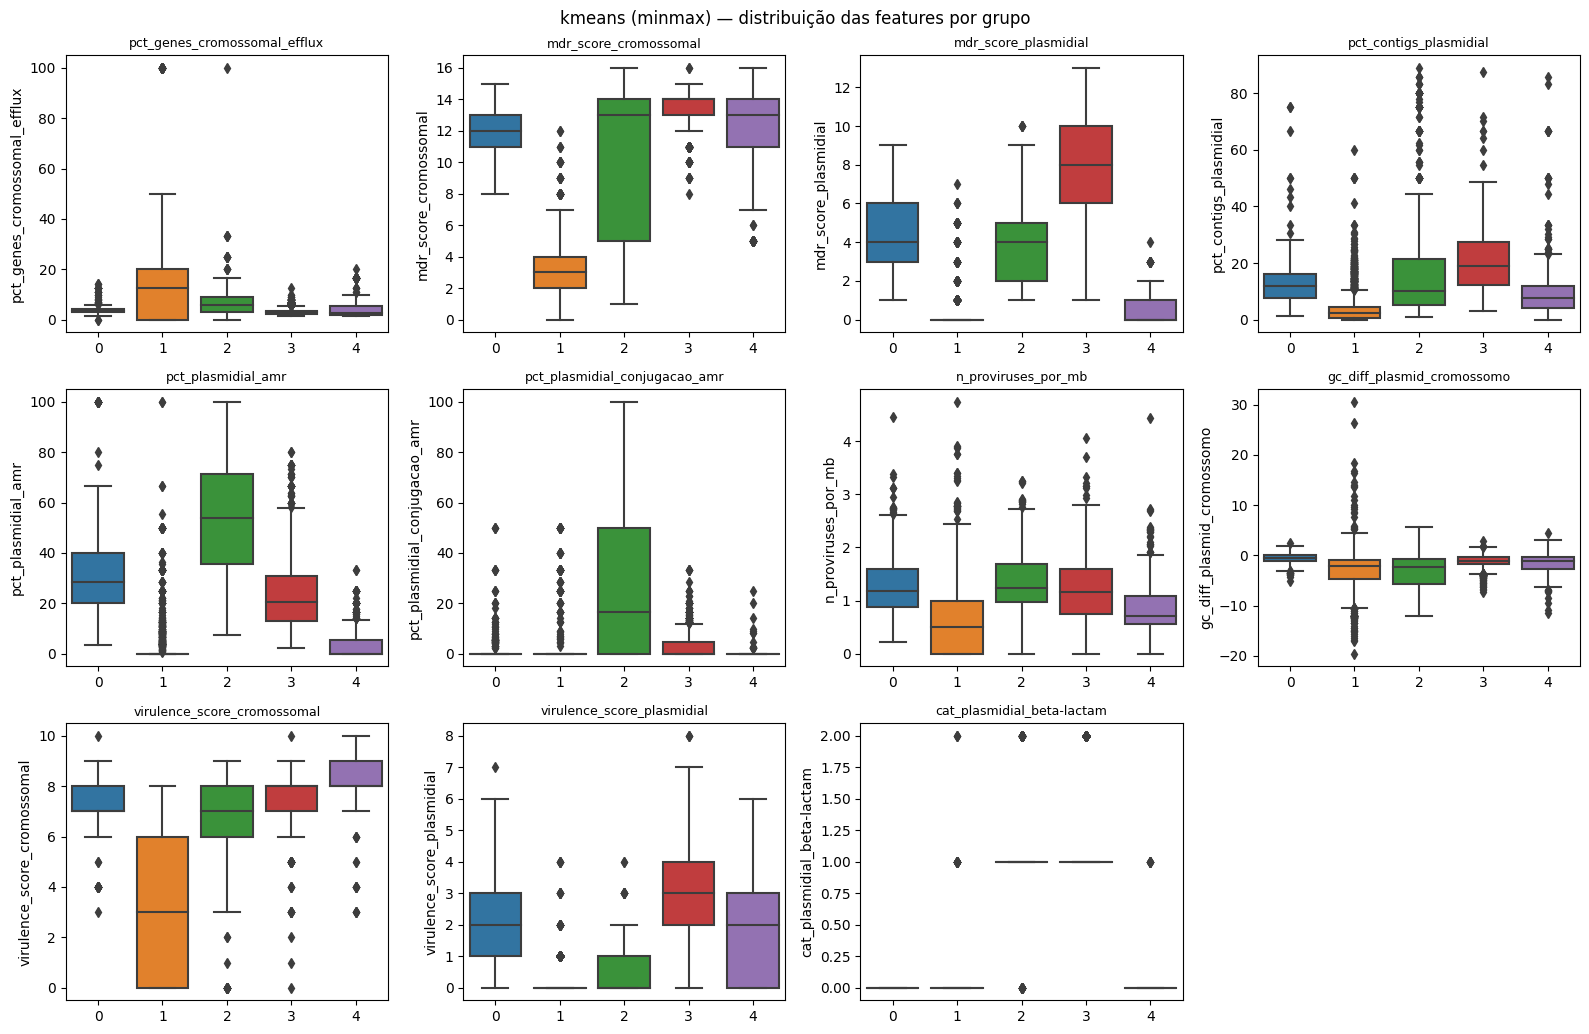

In [ ]:
cluster_kmeans._plot_boxplot()

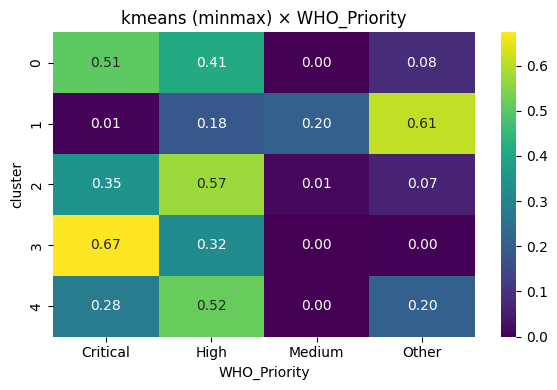

In [ ]:
cluster_kmeans._plot_heatmap_categorico(metadata_alinhado["WHO_Priority"], nome="WHO_Priority")

## Agglomerative

In [ ]:
cluster_agg = Clustering(colunas_X, df_train, "agglomerative")
cluster_agg.preparar_dados("sem_scaling")

# grid search + cross-validation juntos
tabela_grid = cluster_agg.buscar_grid()
tabela_grid.sort_values("ari_estabilidade", ascending=False)

/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 11 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 8 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 10 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 8 > 1. Completing it to a

,n_clusters,linkage,n_ruido,silhouette,calinski_harabasz,davies_bouldin,ari_estabilidade,ari_estabilidade_std
8,4,average,0,0.539478,226.276265,0.340142,0.761537,0.163128
14,6,average,0,0.416615,263.302523,0.498796,0.662321,0.124737
11,5,average,0,0.539719,175.129696,0.310686,0.656274,0.183031
9,5,ward,0,0.324981,1948.917533,0.870853,0.653354,0.143920
6,4,ward,0,0.297342,1736.517051,0.932566,0.642475,0.146166
3,3,ward,0,0.279631,1784.490773,1.236735,0.635304,0.147101
12,6,ward,0,0.273230,1938.464888,1.009292,0.622677,0.117751
2,2,average,0,0.701930,233.584573,0.270475,0.559195,0.390753
5,3,average,0,0.555343,124.524556,0.343022,0.470579,0.338458
0,2,ward,0,0.425581,2087.670118,1.258401,0.414936,0.341389


In [ ]:
tabela_grid.style \
    .apply(
        lambda s: destacar_top2(s, metricas[s.name]),
        subset=list(metricas.keys())
    )

,n_clusters,linkage,n_ruido,silhouette,calinski_harabasz,davies_bouldin,ari_estabilidade,ari_estabilidade_std
0,2,ward,0,0.425581,2087.670118,1.258401,0.414936,0.341389
1,2,complete,0,0.701930,233.584573,0.270475,0.218655,0.294546
2,2,average,0,0.701930,233.584573,0.270475,0.559195,0.390753
3,3,ward,0,0.279631,1784.490773,1.236735,0.635304,0.147101
4,3,complete,0,0.242075,122.494776,0.557758,0.201162,0.229279
5,3,average,0,0.555343,124.524556,0.343022,0.470579,0.338458
6,4,ward,0,0.297342,1736.517051,0.932566,0.642475,0.146166
7,4,complete,0,0.214272,86.836045,0.512893,0.345692,0.309232
8,4,average,0,0.539478,226.276265,0.340142,0.761537,0.163128
9,5,ward,0,0.324981,1948.917533,0.870853,0.653354,0.143920


/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 11 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Calculando métricas para: agglomerative

Silhouette Score -> 0.28
Calinski Harabasz Score -> 1784.491
Davies Bouldin Score -> 1.237


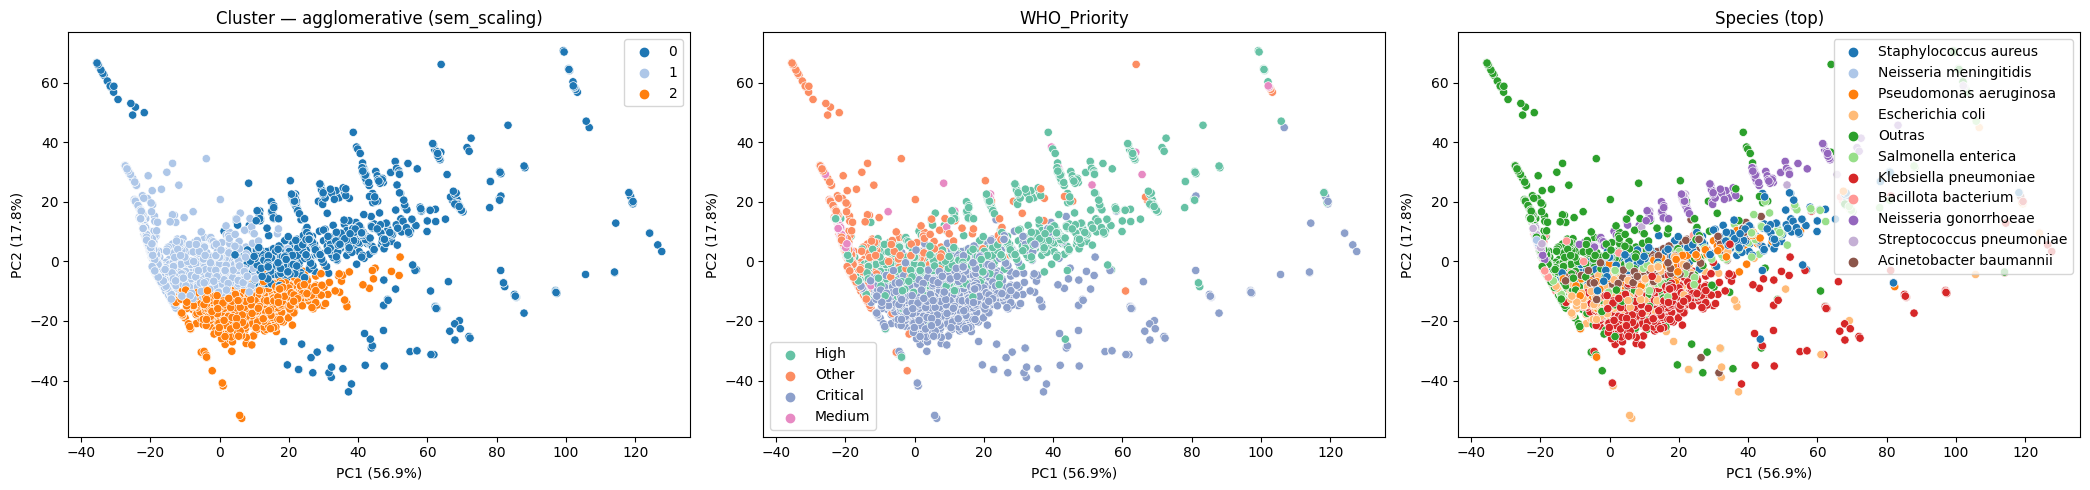

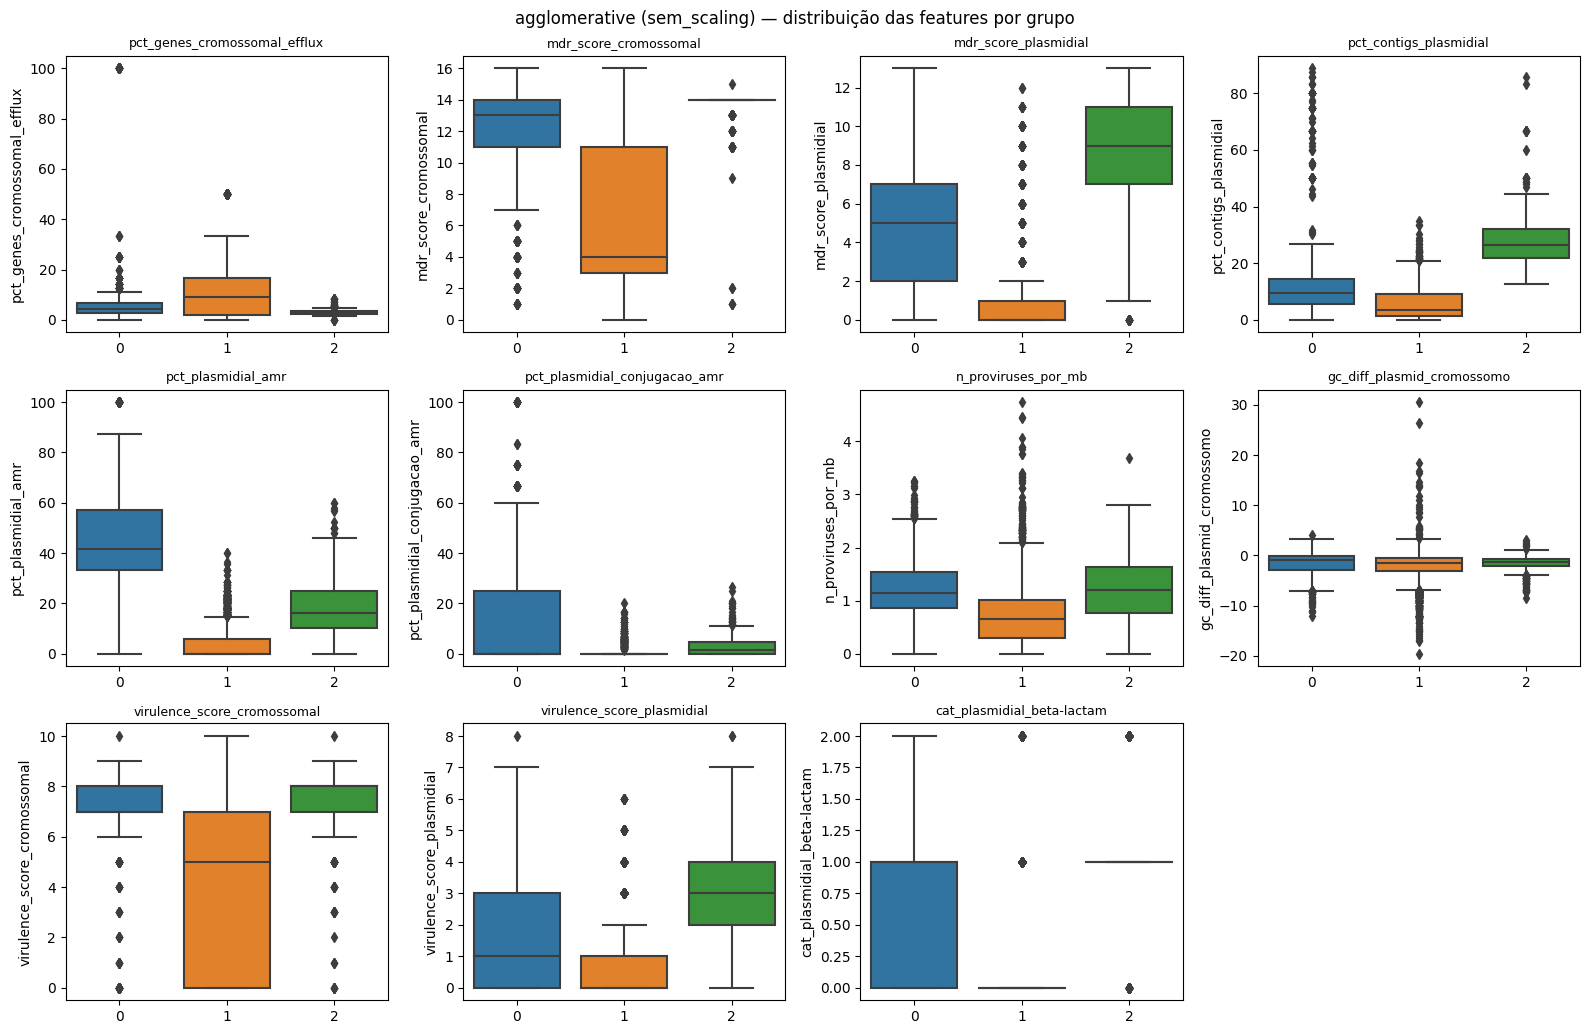

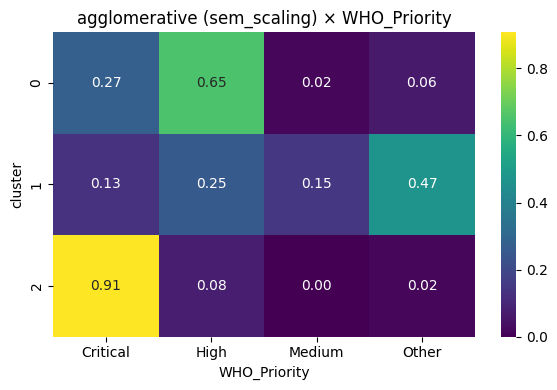

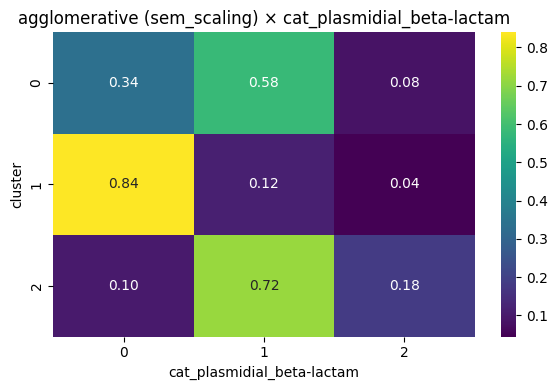

In [ ]:
cluster_agg.ajustar(n_clusters=3, linkage="ward")
cluster_agg.calcular_metricas()

cluster_agg._plot_com_pca(metadata_alinhado, especie_plot_completo)
cluster_agg._plot_boxplot()
cluster_agg._plot_heatmap_categorico(metadata_alinhado["WHO_Priority"], nome="WHO_Priority")
cluster_agg._plot_heatmap_categorico(df_train['cat_plasmidial_beta-lactam'], nome="cat_plasmidial_beta-lactam")

In [ ]:
resultado_valid = cluster_agg.validar_do_zero(df_valid, nome="valid")


--- Validação do zero em 'valid' (agglomerative, minmax) ---
Calculando métricas para: agglomerative (valid)

Silhouette Score -> 0.282
Calinski Harabasz Score -> 342.582
Davies Bouldin Score -> 1.48
Qui-quadrado (distribuição de tamanho de cluster): chi2=52.42, p=0.0000


/usr/local/lib/python3.10/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 5 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Calculando métricas para: agglomerative

Silhouette Score -> 0.365
Calinski Harabasz Score -> 3531.274
Davies Bouldin Score -> 1.176


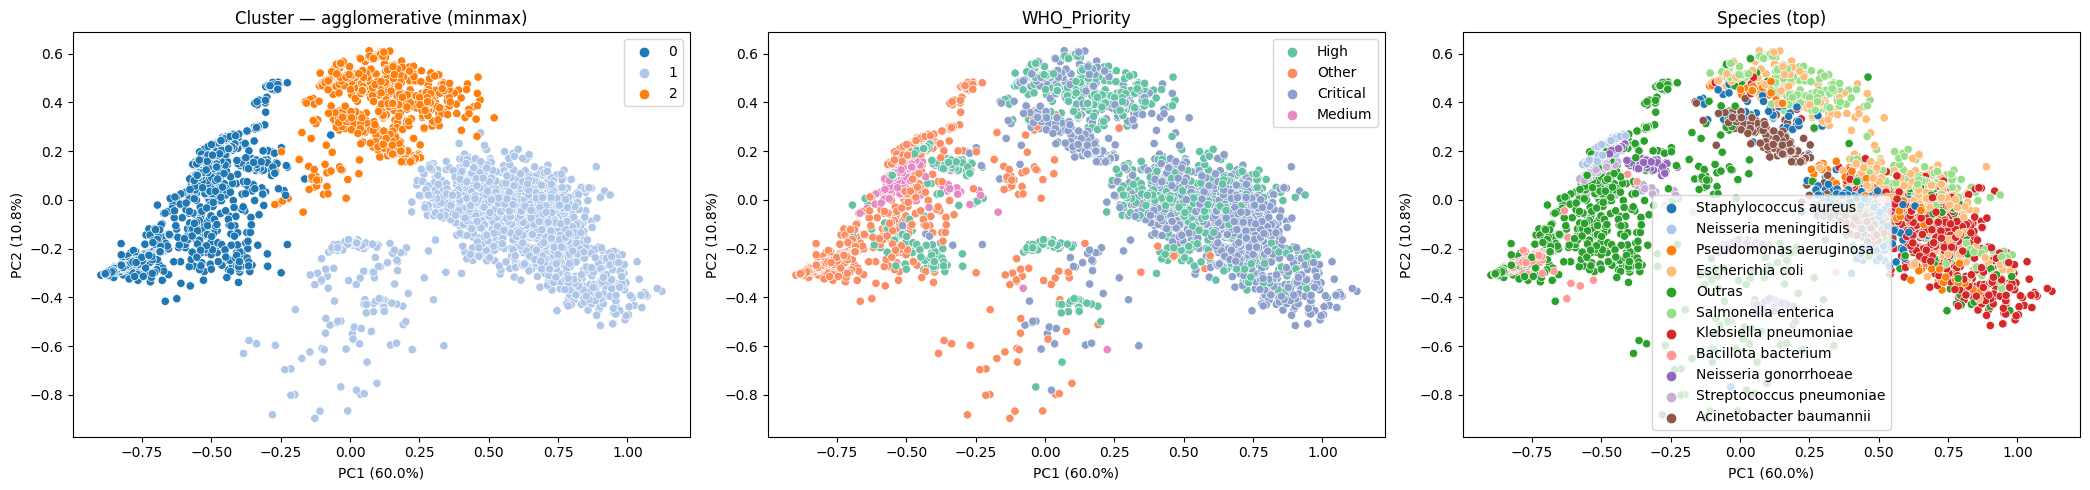

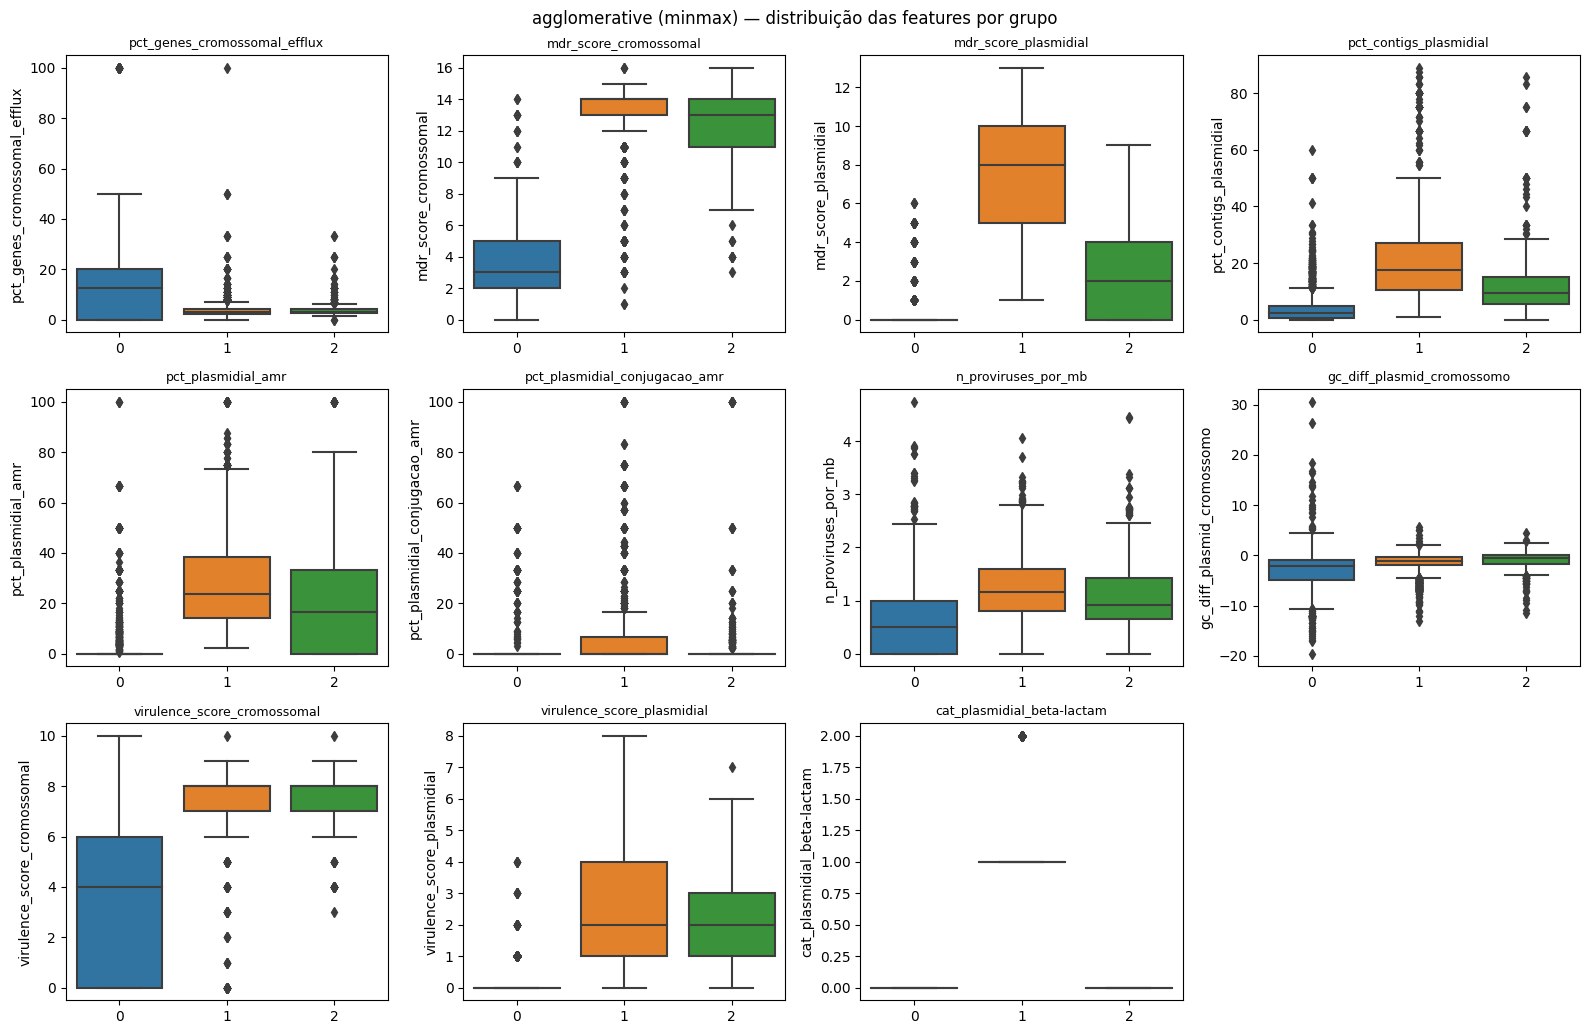

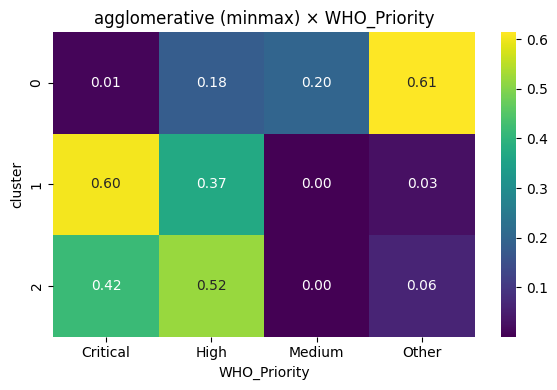

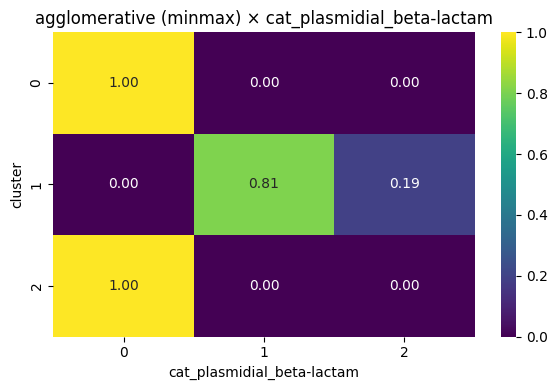


--- Validação do zero em 'valid' (agglomerative, minmax) ---
Calculando métricas para: agglomerative (valid)

Silhouette Score -> 0.354
Calinski Harabasz Score -> 518.889
Davies Bouldin Score -> 1.209
Qui-quadrado (distribuição de tamanho de cluster): chi2=0.97, p=0.6154


In [ ]:
cluster_agg.ajustar(n_clusters=3, linkage="ward")
cluster_agg.calcular_metricas()

cluster_agg._plot_com_pca(metadata_alinhado, especie_plot_completo)
cluster_agg._plot_boxplot()
cluster_agg._plot_heatmap_categorico(metadata_alinhado["WHO_Priority"], nome="WHO_Priority")
cluster_agg._plot_heatmap_categorico(df_train['cat_plasmidial_beta-lactam'], nome="cat_plasmidial_beta-lactam")
resultado_valid = cluster_agg.validar_do_zero(df_valid, nome="valid")